<a href="https://colab.research.google.com/github/ozhao1323/ECON3916-Statistical-and-Machine-Learning/blob/main/Assignment%203/Econ_3916_Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


In [ ]:
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

n_bootstraps = 10_000
bootstrap_medians = np.array([
    np.median(np.random.choice(driver_tips, size=len(driver_tips), replace=True))
    for _ in range(n_bootstraps)
])

ci_lower, ci_upper = np.percentile(bootstrap_medians, [2.5, 97.5])
observed_median = np.median(driver_tips)

print(f"Observed Median: ${observed_median:.4f}")
print(f"95% Bootstrap CI: (${ci_lower:.4f}, ${ci_upper:.4f})")
print(f"CI Width: ${ci_upper - ci_lower:.4f}")
print(f"Left tail width:  ${observed_median - ci_lower:.4f}")
print(f"Right tail width: ${ci_upper - observed_median:.4f}")

Observed Median: $0.7553
95% Bootstrap CI: ($0.2653, $1.3636)
CI Width: $1.0983
Left tail width:  $0.4900
Right tail width: $0.6082


In [ ]:
np.random.seed(42)

control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_diff = np.mean(control) - np.mean(treatment)

print(f"Control mean:   {np.mean(control):.4f} min")
print(f"Treatment mean: {np.mean(treatment):.4f} min")
print(f"Observed difference (Control - Treatment): {observed_diff:.4f} min")

combined = np.concatenate([control, treatment])

n_permutations = 5_000
perm_diffs = np.array([
    np.mean(perm := np.random.permutation(combined)[:500]) - np.mean(perm[500:])
    for _ in range(n_permutations)
])

p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

print(f"\nPermutation Test Results ({n_permutations:,} iterations):")
print(f"Empirical p-value: {p_value:.4f}")
print(f"Significant at α=0.05: {p_value < 0.05}")

Control mean:   35.0342 min
Treatment mean: 32.7692 min
Observed difference (Control - Treatment): 2.2650 min


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



Permutation Test Results (5,000 iterations):
Empirical p-value: 0.0000
Significant at α=0.05: True


In [ ]:
df = pd.read_csv('swiftcart_loyalty.csv')

subscribers     = df[df['subscriber'] == 1]['post_spend']
non_subscribers = df[df['subscriber'] == 0]['post_spend']

naive_sdo = subscribers.mean() - non_subscribers.mean()
print(f"Subscriber mean spending:     ${subscribers.mean():.2f}")
print(f"Non-Subscriber mean spending: ${non_subscribers.mean():.2f}")
print(f"Naive SDO:                    ${naive_sdo:.2f}")

covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
D = df['subscriber']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_scaled, D)
df['propensity_score'] = lr.predict_proba(X_scaled)[:, 1]

treated = df[df['subscriber'] == 1].copy()
control = df[df['subscriber'] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()].copy()

att = treated['post_spend'].values - matched_control['post_spend'].values
ATT = att.mean()

print(f"\nPropensity Score Matching Results:")
print(f"Matched pairs: {len(treated)}")
print(f"ATT (causal estimate): ${ATT:.2f}")
print(f"Selection bias component: ${naive_sdo - ATT:.2f}")

Subscriber mean spending:     $74.04
Non-Subscriber mean spending: $56.47
Naive SDO:                    $17.57

Propensity Score Matching Results:
Matched pairs: 4200
ATT (causal estimate): $10.02
Selection bias component: $7.55


Naive SDO : $17.57
Causal ATT: $10.02
Selection bias removed: $7.55


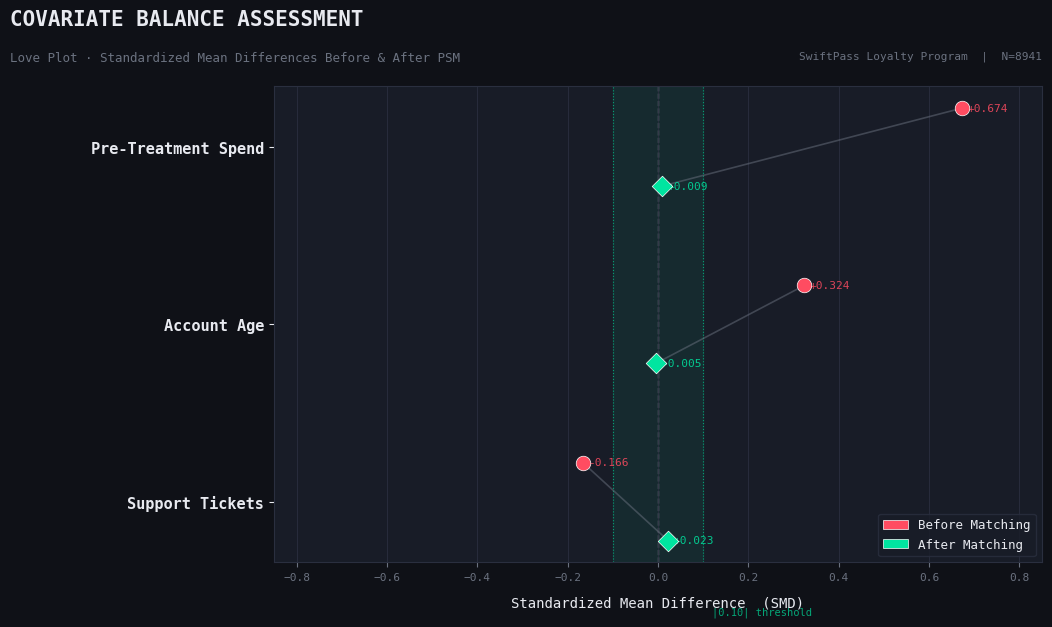

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# ── Phase 3 : PSM Setup ─────────────────────────────────────────────────────
df = pd.read_csv('swiftcart_loyalty.csv')

subscribers     = df[df['subscriber'] == 1]['post_spend']
non_subscribers = df[df['subscriber'] == 0]['post_spend']
naive_sdo       = subscribers.mean() - non_subscribers.mean()

covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
D = df['subscriber']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_scaled, D)
df['propensity_score'] = lr.predict_proba(X_scaled)[:, 1]

treated         = df[df['subscriber'] == 1].copy()
control         = df[df['subscriber'] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])
distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()].copy()

att = treated['post_spend'].values - matched_control['post_spend'].values
ATT = att.mean()

print(f"Naive SDO : ${naive_sdo:.2f}")
print(f"Causal ATT: ${ATT:.2f}")
print(f"Selection bias removed: ${naive_sdo - ATT:.2f}")

# ── Reconstruct unmatched / matched frames ──────────────────────────────────
df_unmatched = df.copy()
df_matched   = pd.concat([
    treated.reset_index(drop=True),
    matched_control.reset_index(drop=True)
], ignore_index=True)

# ── SMD Function ────────────────────────────────────────────────────────────
def compute_smd(df, covariates, treatment_col='subscriber'):
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]
    smds = {}
    for col in covariates:
        mean_t     = treated[col].mean()
        mean_c     = control[col].mean()
        pooled_std = np.sqrt((treated[col].std()**2 + control[col].std()**2) / 2)
        smds[col]  = (mean_t - mean_c) / pooled_std if pooled_std > 0 else 0.0
    return smds

smd_before = compute_smd(df_unmatched, covariates)
smd_after  = compute_smd(df_matched,   covariates)

# ── Plot DataFrame ──────────────────────────────────────────────────────────
plot_df = pd.DataFrame({
    'Covariate': list(smd_before.keys()) * 2,
    'SMD'      : list(smd_before.values()) + list(smd_after.values()),
    'Stage'    : ['Before Matching'] * len(covariates) + ['After Matching'] * len(covariates)
}).assign(AbsSMD=lambda d: d['SMD'].abs())

label_map = {
    'pre_spend'       : 'Pre-Treatment Spend',
    'account_age'     : 'Account Age',
    'support_tickets' : 'Support Tickets',
}
plot_df['Covariate'] = plot_df['Covariate'].map(label_map)
order = (plot_df[plot_df['Stage'] == 'Before Matching']
         .sort_values('AbsSMD', ascending=True)['Covariate'].tolist())

# ── Style ───────────────────────────────────────────────────────────────────
DARK_BG   = '#0F1117'
PANEL_BG  = '#181C27'
GRID_COL  = '#2A2F3F'
ACCENT_R  = '#FF4C61'
ACCENT_G  = '#00E5A0'
TEXT_COL  = '#E8EAF0'
MUTED     = '#6B7280'
THRESHOLD = 0.1

plt.rcParams.update({
    'figure.facecolor' : DARK_BG,
    'axes.facecolor'   : PANEL_BG,
    'axes.edgecolor'   : GRID_COL,
    'axes.labelcolor'  : TEXT_COL,
    'xtick.color'      : MUTED,
    'ytick.color'      : TEXT_COL,
    'text.color'       : TEXT_COL,
    'grid.color'       : GRID_COL,
    'grid.linewidth'   : 0.6,
    'font.family'      : 'monospace',
})

# ── Figure ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 7), facecolor=DARK_BG)
gs  = GridSpec(1, 1, figure=fig, left=0.28, right=0.92, top=0.82, bottom=0.14)
ax  = fig.add_subplot(gs[0, 0])

y_pos   = np.arange(len(order))
spacing = 0.22

before_df = plot_df[plot_df['Stage'] == 'Before Matching'].set_index('Covariate').loc[order]
after_df  = plot_df[plot_df['Stage'] == 'After Matching'].set_index('Covariate').loc[order]

ax.axvspan(-THRESHOLD, THRESHOLD, color='#00E5A0', alpha=0.07, zorder=0)
ax.axvline(0,           color=MUTED,    lw=1.0, ls='--', zorder=1)
ax.axvline( THRESHOLD,  color=ACCENT_G, lw=0.8, ls=':',  zorder=1, alpha=0.6)
ax.axvline(-THRESHOLD,  color=ACCENT_G, lw=0.8, ls=':',  zorder=1, alpha=0.6)

for i, cov in enumerate(order):
    ax.plot([before_df.loc[cov,'SMD'], after_df.loc[cov,'SMD']],
            [y_pos[i] + spacing, y_pos[i] - spacing],
            color=MUTED, lw=1.2, ls='-', alpha=0.5, zorder=2)

ax.scatter(before_df['SMD'], y_pos + spacing,
           color=ACCENT_R, s=110, zorder=4, edgecolors='white', linewidths=0.5)
ax.scatter(after_df['SMD'],  y_pos - spacing,
           color=ACCENT_G, s=110, zorder=4, marker='D', edgecolors='white', linewidths=0.5)

for i, cov in enumerate(order):
    ax.text(before_df.loc[cov,'SMD'] + 0.012, y_pos[i] + spacing,
            f"{before_df.loc[cov,'SMD']:+.3f}", va='center', fontsize=8, color=ACCENT_R, alpha=0.85)
    ax.text(after_df.loc[cov,'SMD']  + 0.012, y_pos[i] - spacing,
            f"{after_df.loc[cov,'SMD']:+.3f}",  va='center', fontsize=8, color=ACCENT_G, alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(order, fontsize=11, fontweight='bold')
ax.set_xlabel('Standardized Mean Difference  (SMD)', fontsize=10, labelpad=10)
ax.set_xlim(-0.85, 0.85)
ax.xaxis.grid(True, zorder=0)
ax.yaxis.grid(False)
ax.tick_params(axis='x', labelsize=8)
ax.text(THRESHOLD + 0.02, -0.65, '|0.10| threshold',
        color=ACCENT_G, fontsize=7.5, alpha=0.7, va='bottom')

legend_elements = [
    mpatches.Patch(facecolor=ACCENT_R, label='Before Matching', edgecolor='white', linewidth=0.5),
    mpatches.Patch(facecolor=ACCENT_G, label='After Matching',  edgecolor='white', linewidth=0.5),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          facecolor=PANEL_BG, edgecolor=GRID_COL, labelcolor=TEXT_COL)

fig.text(0.06, 0.93, "COVARIATE BALANCE ASSESSMENT",
         fontsize=15, fontweight='bold', color=TEXT_COL, va='top')
fig.text(0.06, 0.87, "Love Plot · Standardized Mean Differences Before & After PSM",
         fontsize=9, color=MUTED, va='top')
fig.text(0.92, 0.87, f"SwiftPass Loyalty Program  |  N={len(df_unmatched)}",
         fontsize=8, color=MUTED, va='top', ha='right')

plt.savefig('love_plot.png', dpi=180, bbox_inches='tight', facecolor=DARK_BG)
plt.show()